<a href="https://colab.research.google.com/github/Rafa-Cami/CD-Norton/blob/main/EP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

vamos começar LET'S GO BITCHESSSSS

# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay

# Seed

Seed definida para garantir reprodutibilidade

In [3]:
seed = 42

random.seed(seed)
np.random.seed(seed)

### Importando o conjunto de dados 

In [5]:
df = pd.read_csv('subamostra_90_porcento.csv')
df.head(10)

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,47,Female,Single,High School,Unemployed,5.3,1.5,7.2,8,5,...,5,4,6,3,1,1,1,1,0,1
1,53,Other,Single,Bachelor,Employed,4.8,0.5,5.6,8,4,...,7,1,2,5,1,1,0,0,0,2
2,43,Male,Single,Bachelor,Student,6.4,6.9,10.2,4,1,...,8,9,9,5,1,0,1,1,0,1
3,18,Other,Married,High School,Unemployed,9.6,0.4,7.4,6,6,...,7,5,7,3,0,0,1,0,1,0
4,23,Female,Divorced,Master,Self-Employed,9.0,1.3,5.1,6,3,...,4,5,7,7,0,1,0,0,0,0
5,53,Female,Married,High School,Unemployed,7.9,14.3,6.9,8,5,...,3,6,8,10,0,0,0,0,1,0
6,45,Other,Married,Master,Student,8.2,2.0,3.0,2,8,...,2,7,1,3,0,1,0,1,1,1
7,23,Other,Divorced,Master,Employed,7.8,4.7,9.1,7,6,...,6,10,3,7,0,0,1,1,1,0
8,42,Other,Single,Bachelor,Student,9.5,9.0,9.8,7,2,...,8,3,6,1,1,1,1,1,0,1
9,34,Female,Divorced,PhD,Employed,6.7,5.2,2.6,7,8,...,8,8,10,6,1,1,0,1,1,2


# Funções de plots das métricas

# Tratamento da base

### Tratamento das variáveis categóricas texto para numéricas

Mapeamento manual Ordinal encoding para não perder a ordem lógica da variável `education_level`

In [6]:
# Defina a ordem correta baseada nos dados que você tem
mapa_educacao = {
    'High School': 1,
    'Bachelor': 2,
    'Master': 3,
    'PhD': 4  # adicione outras categorias se houver
}

df_edu = df.copy()

df_edu['education_level'] = df_edu['education_level'].map(mapa_educacao)
df_edu.head(10)


,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,47,Female,Single,1,Unemployed,5.3,1.5,7.2,8,5,...,5,4,6,3,1,1,1,1,0,1
1,53,Other,Single,2,Employed,4.8,0.5,5.6,8,4,...,7,1,2,5,1,1,0,0,0,2
2,43,Male,Single,2,Student,6.4,6.9,10.2,4,1,...,8,9,9,5,1,0,1,1,0,1
3,18,Other,Married,1,Unemployed,9.6,0.4,7.4,6,6,...,7,5,7,3,0,0,1,0,1,0
4,23,Female,Divorced,3,Self-Employed,9.0,1.3,5.1,6,3,...,4,5,7,7,0,1,0,0,0,0
5,53,Female,Married,1,Unemployed,7.9,14.3,6.9,8,5,...,3,6,8,10,0,0,0,0,1,0
6,45,Other,Married,3,Student,8.2,2.0,3.0,2,8,...,2,7,1,3,0,1,0,1,1,1
7,23,Other,Divorced,3,Employed,7.8,4.7,9.1,7,6,...,6,10,3,7,0,0,1,1,1,0
8,42,Other,Single,2,Student,9.5,9.0,9.8,7,2,...,8,3,6,1,1,1,1,1,0,1
9,34,Female,Divorced,4,Employed,6.7,5.2,2.6,7,8,...,8,8,10,6,1,1,0,1,1,2


One-hot encoding para as variáveis `gender`, `marital_status` e `employment_status`

In [7]:
df_tratado = pd.get_dummies(df_edu, columns=['gender', 'marital_status', 'employment_status'], dtype=int)
df_tratado.head(10)
# df_tratado.head(0)

,age,education_level,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,...,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,marital_status_Single,employment_status_Employed,employment_status_Self-Employed,employment_status_Student,employment_status_Unemployed
0,47,1,5.3,1.5,7.2,8,5,8,10,10,...,1,0,0,0,0,1,0,0,0,1
1,53,2,4.8,0.5,5.6,8,4,7,7,10,...,0,0,1,0,0,1,1,0,0,0
2,43,2,6.4,6.9,10.2,4,1,5,8,4,...,0,1,0,0,0,1,0,0,1,0
3,18,1,9.6,0.4,7.4,6,6,9,8,5,...,0,0,1,0,1,0,0,0,0,1
4,23,3,9.0,1.3,5.1,6,3,9,10,7,...,1,0,0,1,0,0,0,1,0,0
5,53,1,7.9,14.3,6.9,8,5,3,8,4,...,1,0,0,0,1,0,0,0,0,1
6,45,3,8.2,2.0,3.0,2,8,2,1,10,...,0,0,1,0,1,0,0,0,1,0
7,23,3,7.8,4.7,9.1,7,6,9,4,10,...,0,0,1,1,0,0,1,0,0,0
8,42,2,9.5,9.0,9.8,7,2,6,8,4,...,0,0,1,0,0,1,0,0,1,0
9,34,4,6.7,5.2,2.6,7,8,7,5,10,...,1,0,0,1,0,0,1,0,0,0


### Verificando a proporção da variavel alvo no conjunto de dados

In [8]:
contagem_risco = df['mental_health_risk'].value_counts()
print(contagem_risco)

mental_health_risk
1    10667
0     8392
2     3441
Name: count, dtype: int64


Um pouco desproporcional, cenário onde seria melhor fazer um cross validation estratificado

### Mapeamento das variáveis para os fatores

In [9]:
mapeamento_fatores = {
    # --- Estilo de Vida ---
    'sleep_hours': 'Estilo de Vida',
    'physical_activity_hours_per_week': 'Estilo de Vida',
    'screen_time_hours_per_day': 'Estilo de Vida',
    'working_hours_per_week': 'Estilo de Vida',
    
    # --- Psicológico e Emocional ---
    'anxiety_score': 'Psicológico e Emocional',
    'depression_score': 'Psicológico e Emocional',
    'stress_level': 'Psicológico e Emocional',
    'mood_swings_frequency': 'Psicológico e Emocional',
    'concentration_difficulty_level': 'Psicológico e Emocional',
    
    # --- Socioeconômico e Ocupacional ---
    'age': 'Socioeconômico e Ocupacional',
    'education_level': 'Socioeconômico e Ocupacional',
    'work_stress_level': 'Socioeconômico e Ocupacional',
    'job_satisfaction_score': 'Socioeconômico e Ocupacional',
    'financial_stress_level': 'Socioeconômico e Ocupacional',
    'working_hours_per_week': 'Socioeconômico e Ocupacional',
    'employment_status_Employed': 'Socioeconômico e Ocupacional',
    'employment_status_Self-Employed': 'Socioeconômico e Ocupacional',
    'employment_status_Student': 'Socioeconômico e Ocupacional',
    'employment_status_Unemployed': 'Socioeconômico e Ocupacional',
    
    # --- Suporte Social e Contexto Interpessoal ---
    'gender_Female': 'Suporte Social e Contexto Interpessoal',
    'gender_Male': 'Suporte Social e Contexto Interpessoal',
    'gender_Other': 'Suporte Social e Contexto Interpessoal',
    'social_support_score': 'Suporte Social e Contexto Interpessoal',
    'marital_status_Divorced': 'Suporte Social e Contexto Interpessoal',
    'marital_status_Married': 'Suporte Social e Contexto Interpessoal',
    'marital_status_Single': 'Suporte Social e Contexto Interpessoal',
    
    # --- Histórico Clínico e Comportamental ---
    'panic_attack_history': 'Histórico Clínico e Comportamental',
    'family_history_mental_illness': 'Histórico Clínico e Comportamental',
    'previous_mental_health_diagnosis': 'Histórico Clínico e Comportamental',
    'therapy_history': 'Histórico Clínico e Comportamental',
    'substance_use': 'Estilo de Vida',
}

## Random Forest

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Melhores hiperparâmetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy: 0.9748888888888889
F1 macro: 0.9679218110728502

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1679
           1       0.97      0.97      0.97      2133
           2       0.96      0.92      0.94       688

    accuracy                           0.97      4500
   macro avg       0.97      0.96      0.97      4500
weighted avg       0.97      0.97      0.97      4500


Matriz de confusão:
[[1679    0    0]
 [  32 2077   24]
 [   0   57  631]]

Top 20 features importantes:
sleep_hours                         0.170018
panic_attack_history                0.166114
anxiety_score                       0.164907
depression_score                    0.160228
family_history_mental_illness       0.048580
work_stress_level          

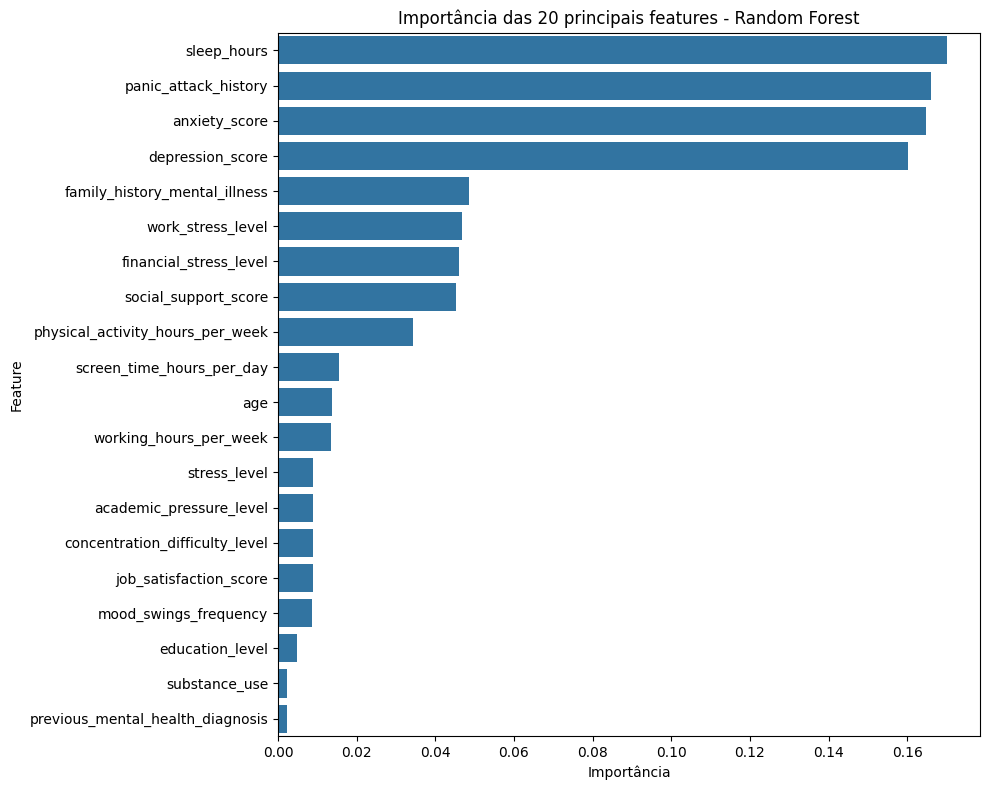

In [10]:
target = 'mental_health_risk'

X = df_tratado.drop(columns=[target])
y = df_tratado[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

rf = RandomForestClassifier(random_state=seed, n_jobs=-1, class_weight='balanced')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
grid = GridSearchCV(rf, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print('Melhores hiperparâmetros:', grid.best_params_)

print('Accuracy:', accuracy_score(y_test, best_rf.predict(X_test)))
print('F1 macro:', f1_score(y_test, best_rf.predict(X_test), average='macro'))

print('\nRelatório de classificação:')
print(classification_report(y_test, best_rf.predict(X_test)))
print('\nMatriz de confusão:')
print(confusion_matrix(y_test, best_rf.predict(X_test)))

feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('\nTop 20 features importantes:')
print(feature_importances.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importances.head(20), y=feature_importances.head(20).index)
plt.title('Importância das 20 principais features - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## XGBoost

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Melhores hiperparâmetros (XGBoost): {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.998
F1 macro: 0.9973947685785695

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1679
           1       1.00      1.00      1.00      2133
           2       1.00      0.99      0.99       688

    accuracy                           1.00      4500
   macro avg       1.00      1.00      1.00      4500
weighted avg       1.00      1.00      1.00      4500



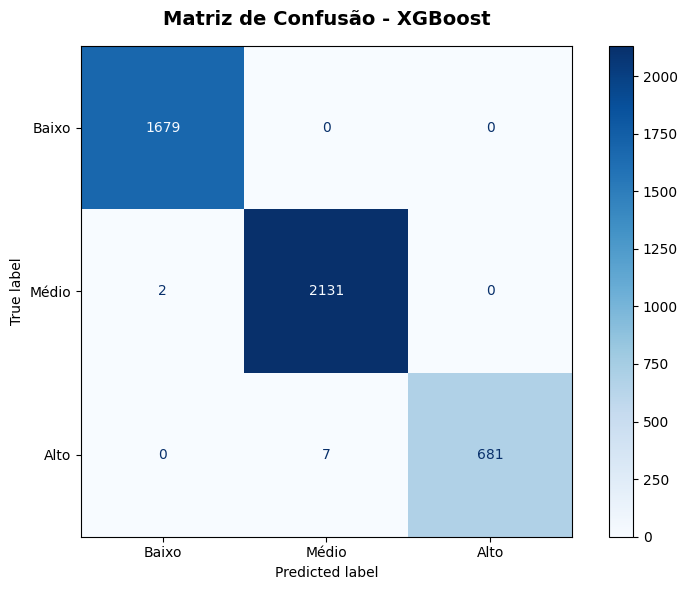


Top 20 features importantes (XGBoost):
depression_score                    0.129375
sleep_hours                         0.127861
anxiety_score                       0.126571
panic_attack_history                0.120411
work_stress_level                   0.088123
financial_stress_level              0.086635
social_support_score                0.086108
family_history_mental_illness       0.068489
physical_activity_hours_per_week    0.054492
previous_mental_health_diagnosis    0.007453
substance_use                       0.006402
age                                 0.006166
employment_status_Unemployed        0.006048
employment_status_Employed          0.005979
stress_level                        0.005574
therapy_history                     0.005369
screen_time_hours_per_day           0.005331
marital_status_Married              0.005190
gender_Male                         0.005062
working_hours_per_week              0.004927
dtype: float32


C:\Users\catar\AppData\Local\Temp\ipykernel_20724\3407878045.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_xgb.head(20), y=feature_importances_xgb.head(20).index, palette='viridis')


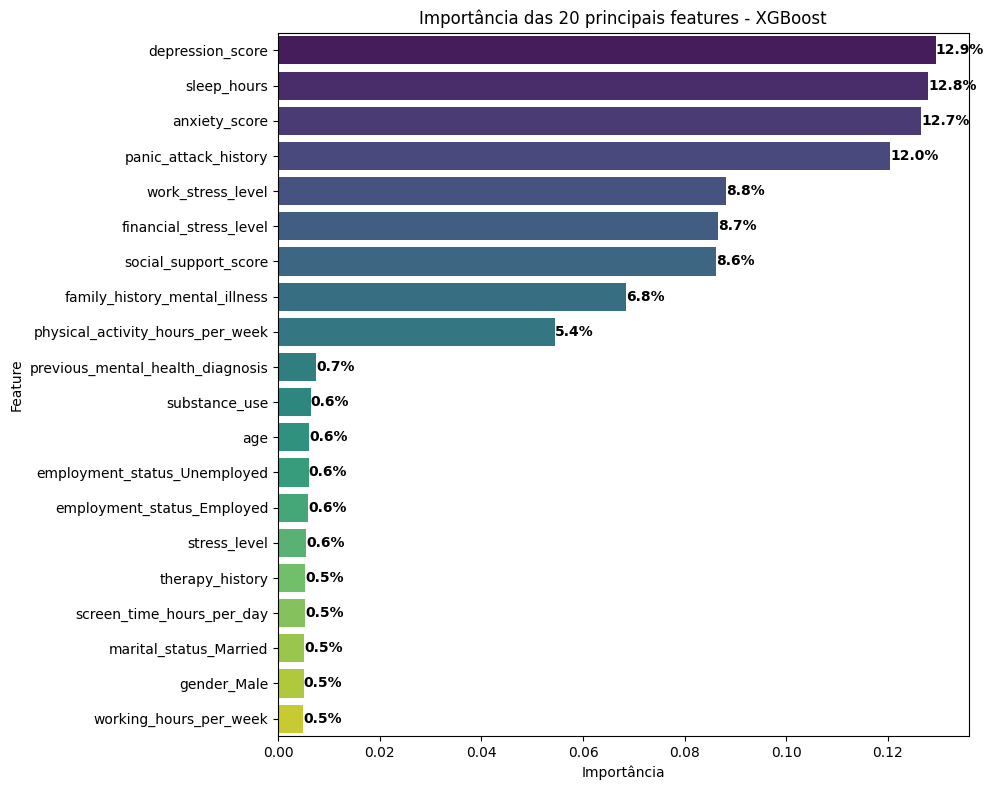

In [11]:
# X_train, X_test, y_train, y_test já foram criados no bloco anterior!

# Instanciar o classificador do XGBoost
# n_jobs=-1 garante o uso de todos os núcleos do processador
xgb_model = xgb.XGBClassifier(random_state=seed, n_jobs=-1, eval_metric='mlogloss')

# Ajustar a grade de hiperparâmetros específica para Gradient Boosting
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],           # Árvores no XGBoost costumam ser mais rasas que no Random Forest
    'learning_rate': [0.01, 0.1, 0.2], # O "passo" de aprendizado a cada nova árvore
    'subsample': [0.8, 1.0]            # Porcentagem de linhas usadas para treinar cada árvore
}

# Configurar a validação cruzada (reutilizando o cv estratificado)
grid_xgb = GridSearchCV(
    estimator=xgb_model, 
    param_grid=param_grid_xgb, 
    cv=cv, 
    scoring='f1_macro', 
    n_jobs=-1, 
    verbose=1
)

# Treinar o modelo
grid_xgb.fit(X_train, y_train)

# Extrair o melhor modelo e parâmetros
best_xgb = grid_xgb.best_estimator_
print('Melhores hiperparâmetros (XGBoost):', grid_xgb.best_params_)

# Avaliação do modelo nos dados de teste
y_pred_xgb = best_xgb.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('F1 macro:', f1_score(y_test, y_pred_xgb, average='macro'))

print('\nRelatório de classificação:')
print(classification_report(y_test, y_pred_xgb))
# print('\nMatriz de confusão:')
# print(confusion_matrix(y_test, y_pred_xgb))

# Matriz de confusão como imagem
plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_xgb, 
    cmap='Blues', 
    ax=plt.gca(),
    display_labels=['Baixo', 'Médio', 'Alto']
)
plt.title('Matriz de Confusão - XGBoost', fontsize=14, fontweight='bold', pad=15)
plt.grid(False)
plt.tight_layout()
plt.show()

# Extração e plotagem da Feature Importance
feature_importances_xgb = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
print('\nTop 20 features importantes (XGBoost):')
print(feature_importances_xgb.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importances_xgb.head(20), y=feature_importances_xgb.head(20).index, palette='viridis')
plt.title('Importância das 20 principais features - XGBoost')
plt.xlabel('Importância')
plt.ylabel('Feature')

# Adicionando os rótulos de porcentagem na frente de cada barra
top_20_features = feature_importances_xgb.head(20)
for index, value in enumerate(top_20_features.values):
    plt.text(value, index, f'{value*100:.1f}%', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### XGBoost: Gráfico de Feature Importance dos 5 fatores definidos 

=== CONTRIBUIÇÃO CONSOLIDADA DOS 5 FATORES CONCEITUAIS ===
Psicológico e Emocional: 27.06%
Socioeconômico e Ocupacional: 21.67%
Histórico Clínico e Comportamental: 20.17%
Estilo de Vida: 19.41%
Suporte Social e Contexto Interpessoal: 11.19%


C:\Users\catar\AppData\Local\Temp\ipykernel_20904\1872801857.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


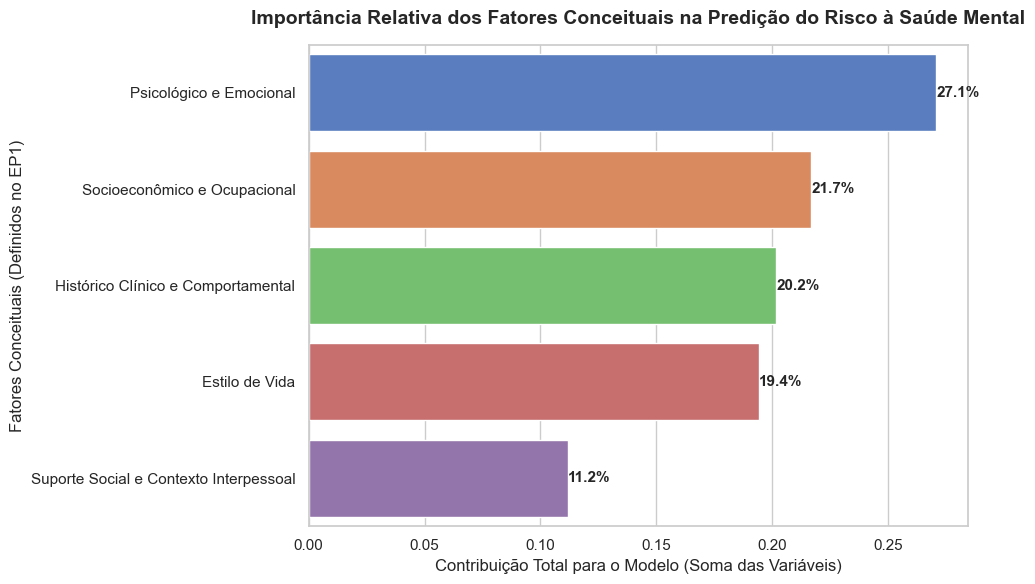

In [ ]:
# Pegar a série de importâncias do XGBoost e transformar em um DataFrame do Pandas
df_importancia = feature_importances_xgb.reset_index()
df_importancia.columns = ['Variavel', 'Importancia']

# Aplicar o dicionário de mapeamento para criar a coluna 'Fator'
df_importancia['Fator'] = df_importancia['Variavel'].map(mapeamento_fatores)

# Agrupar por Fator Conceitual e SOMAR as importâncias
df_fatores = df_importancia.groupby('Fator')['Importancia'].sum().reset_index()

# Ordenar do fator com maior contribuição para o menor
df_fatores = df_fatores.sort_values(by='Importancia', ascending=False)

# Visualização
print("=== CONTRIBUIÇÃO CONSOLIDADA DOS 5 FATORES CONCEITUAIS ===")
for idx, row in df_fatores.iterrows():
    print(f"{row['Fator']}: {row['Importancia']*100:.2f}%")

# Gerar o gráfico de barras para o seu relatório técnico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Cores
grafico = sns.barplot(
    x='Importancia', 
    y='Fator', 
    data=df_fatores, 
    palette='muted'
)

plt.title('Importância Relativa dos Fatores Conceituais na Predição do Risco à Saúde Mental', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Contribuição Total para o Modelo (Soma das Variáveis)', fontsize=12)
plt.ylabel('Fatores Conceituais (Definidos no EP1)', fontsize=12)

# Adicionar a porcentagem exata no final de cada barra 
for index, value in enumerate(df_fatores['Importancia']):
    plt.text(value, index, f'{value*100:.1f}%', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Comparação entre os modelos